# Algorithm Consensus Feature Selection

## Are there features that all algorithms agree are essential?

RobustModelMaker's bootstrap stability selection is always anchored to a specific algorithm.
A Random Forest identifies important features via **MDI** (mean decrease in impurity) —
a criterion that naturally captures non-linear interactions between descriptors.
ElasticNet identifies them via **|coefficient| magnitude** — a linear criterion that
rewards features with a consistent additive relationship to the target.

These are genuinely different perspectives.  A feature that matters only through a
non-linear interaction will be flagged by RF but missed by ElasticNet.  A feature
with a clean linear relationship may rank highly for ElasticNet but be diluted in a
forest of interactions.

**The meta-consensus question:** which features are selected by *all* algorithms?

A feature that survives bootstrap stability selection under four fundamentally different
model families is almost certainly a genuine signal.  It is important *regardless* of
whether the true relationship is linear or non-linear — which means it is the most
transferable and trustworthy part of the feature set.

## Algorithms used

| Code | Model family | Importance criterion | Inductive bias |
|---|---|---|---|
| `eln` | ElasticNet | \|coefficient\| (L1+L2) | Linear, handles collinearity |
| `rdg` | Ridge | \|coefficient\| (L2 only) | Linear, soft shrinkage, does not zero out |
| `las` | Lasso | \|coefficient\| (L1 only) | Linear, aggressive sparsity |
| `rf`  | Random Forest | MDI (variance reduction) | Non-linear, tree-based |

Lasso is included specifically because it is the *most* aggressive linear selector —
if a feature survives Lasso it has an unusually clean linear signal.  Ridge is the
*least* aggressive (it almost never zeroes a coefficient completely), which means
features it excludes are particularly noisy.  Having both in the consensus means a
feature must satisfy both extremes of the linear-sparsity spectrum.

## Dataset

The **Graphene Oxide Bulk** dataset (CSIRO) is used throughout.  It contains
~309 MD-derived structural descriptors (bond lengths, coordination numbers, pair
distribution function moments, angle distributions, etc.) and a regression target:
the DFT-computed formation energy in eV.  Descriptors are correlated — many measure
related geometric quantities — so the consensus analysis is especially meaningful:
features in the consensus are the physical descriptors that most directly govern
the formation energy regardless of how you model the relationship.

> **Data access:** `Graphene_Oxide_Bulk.csv` must be placed in the `tools/` directory
> alongside this notebook.
> See <https://doi.org/10.25919/5e30b45f9852c> for the CSIRO data record.

---
## 1 · Setup

This notebook is **self-contained** — it does not depend on `benchmark_suite.py` or any
other benchmark infrastructure.  The only two things it needs are:

* **`RobustModelMaker.py`** — must be one level above `tools/` (standard repo layout),
  or set `ROBUST_MODEL_MAKER_PATH=/path/to/RobustModelMaker.py` in your environment.
* **`Graphene_Oxide_Bulk.csv`** — must be in the `tools/` directory alongside this notebook.
  Download from: <https://doi.org/10.25919/5e30b45f9852c>

`AlgorithmConsensus` handles locating RobustModelMaker automatically when imported.
Edit `REPO_ROOT` below only if your directory layout differs from the standard repo structure.

In [3]:
%matplotlib inline
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Edit REPO_ROOT if your layout differs ─────────────────────────────────────
REPO_ROOT = Path('.').resolve().parent   # assumes notebook is in tools/
TOOLS_DIR = REPO_ROOT / 'tools'

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(TOOLS_DIR))

# ── Import AlgorithmConsensus ─────────────────────────────────────────────────
# AlgorithmConsensus locates RobustModelMaker automatically (searches REPO_ROOT).
from algorithm_consensus import (
    AlgorithmConsensus,
    ALGORITHM_LABELS,
    DEFAULT_ALGORITHMS,
    DEFAULT_BASE_PARAMS,
)

# ── RobustModelMaker parameters (edit to taste) ───────────────────────────────
ROBUST_PARAMS = dict(
    outer_cv            = 10,
    inner_cv            = 5,
    n_bootstrap         = 25,
    n_iter              = 10,
    stability_threshold = 0.75,
    cutoff_n_bootstrap  = 100,
    random_state        = 42,
    n_jobs              = 1,
    verbose             = False,
)

print('Setup complete.')
print(f'  REPO_ROOT           : {REPO_ROOT}')
print(f'  TOOLS_DIR           : {TOOLS_DIR}')
print()
print('Available algorithms :', list(ALGORITHM_LABELS.keys()))
print('Regression defaults  :', DEFAULT_ALGORITHMS['regression'])
print(f'stability_threshold  : {ROBUST_PARAMS["stability_threshold"]}')

Setup complete.
  REPO_ROOT           : C:\Users\Amanda\Favorites\Machine Learning\RobustModelMaker
  TOOLS_DIR           : C:\Users\Amanda\Favorites\Machine Learning\RobustModelMaker\tools

Available algorithms : ['eln', 'rdg', 'las', 'lin', 'log', 'rf', 'xgb', 'svm', 'mlp']
Regression defaults  : ['eln', 'rdg', 'las', 'rf']
stability_threshold  : 0.75


---
## 2 · Configuration

### Algorithms

Four algorithms are used to span the space from aggressive linear sparsity to
non-linear tree-based selection:

```
eln  ElasticNet   — linear, L1+L2 — designed for correlated feature sets
rdg  Ridge        — linear, L2    — softest linear selector, rarely zeros out
las  Lasso        — linear, L1    — most aggressive linear selector
rf   Random Forest— MDI           — fully non-linear, tree-based
```

Add `'xgb'` to the list if XGBoost is installed (`pip install xgboost`).

### `min_agreement`

| `min_agreement` | Meaning with 4 algorithms |
|---|---|
| `1.00` (default) | All 4 must agree — strictest consensus |
| `0.75` | At least 3 of 4 must agree |
| `0.50` | At least 2 of 4 must agree — majority vote |

Start with `1.0` and lower if the strict consensus is too small for downstream use.

### Base params

The same structural params as the benchmark are used (`outer_cv=10`, `inner_cv=5`,
`n_bootstrap=25`, `stability_threshold=0.75`) so results are directly comparable.
Set `QUICK_RUN = True` to use reduced settings for fast exploration.

In [5]:
# ── Algorithm selection ───────────────────────────────────────────────────────
ALGORITHMS = ['eln', 'rdg', 'las', 'rf']
# ALGORITHMS += ['xgb']   # uncomment if XGBoost is installed

# ── Consensus threshold ───────────────────────────────────────────────────────
MIN_AGREEMENT = 1.0   # 1.0 = all algorithms must agree

# ── Speed mode ────────────────────────────────────────────────────────────────
QUICK_RUN = True   # set False for full benchmark-quality settings

if QUICK_RUN:
    _nb = 10
    _ni = 5
    _ov = 5
    print('Mode: QUICK RUN  (n_bootstrap=10, n_iter=5, outer_cv=5)')
    print('      Set QUICK_RUN = False to use full benchmark settings.')
else:
    _nb = ROBUST_PARAMS['n_bootstrap']    # 25
    _ni = ROBUST_PARAMS['n_iter']         # 10
    _ov = ROBUST_PARAMS['outer_cv']       # 10
    print('Mode: FULL RUN  (benchmark-quality settings)')

BASE_PARAMS = dict(
    outer_cv           = _ov,
    inner_cv           = ROBUST_PARAMS['inner_cv'],   # 5
    n_bootstrap        = _nb,
    n_iter             = _ni,
    stability_threshold= ROBUST_PARAMS['stability_threshold'],  # 0.75
    cutoff_n_bootstrap = ROBUST_PARAMS['cutoff_n_bootstrap'],   # 100
    random_state       = ROBUST_PARAMS['random_state'],         # 42
    n_jobs             = 1,    # set -1 to use all cores
    verbose            = False,
)

print()
print(f'Algorithms     : {ALGORITHMS}')
print(f'min_agreement  : {MIN_AGREEMENT}  ({int(MIN_AGREEMENT * len(ALGORITHMS))}/{len(ALGORITHMS)} must agree)')
_thr = BASE_PARAMS['stability_threshold']
_ov2 = BASE_PARAMS['outer_cv']
_iv  = BASE_PARAMS['inner_cv']
print(f'threshold      : {_thr}  |  outer_cv={_ov2}  inner_cv={_iv}  n_bootstrap={_nb}  n_iter={_ni}')
print(f'Est. time      : ~{len(ALGORITHMS) * 5}\u2013{len(ALGORITHMS) * 15} min total (Graphene, single core)')

Mode: QUICK RUN  (n_bootstrap=10, n_iter=5, outer_cv=5)
      Set QUICK_RUN = False to use full benchmark settings.

Algorithms     : ['eln', 'rdg', 'las', 'rf']
min_agreement  : 1.0  (4/4 must agree)
threshold      : 0.75  |  outer_cv=5  inner_cv=5  n_bootstrap=10  n_iter=5
Est. time      : ~20–60 min total (Graphene, single core)


---
## 3 · Load Graphene Oxide Bulk

The loader handles data cleaning (dropping constant and fully-NaN columns) from the raw CSV.
A **random 80/20 split** (`random_state=42`) is then applied rather than the adversarial
benchmark partition.

Algorithm consensus answers the question *"which features do all inductive biases agree are
important?"* — and that question should be answered under representative training conditions,
not a worst-case split.  The held-out test set is never touched during the consensus analysis.

In [7]:
TASK_TYPE = 'regression'   # Formation_energy is a continuous regression target

CSV_PATH = TOOLS_DIR / 'Graphene_Oxide_Bulk.csv'

if not CSV_PATH.exists():
    print(f'SKIP: Graphene_Oxide_Bulk.csv not found at {CSV_PATH}')
    print()
    print('Download the dataset from: https://doi.org/10.25919/5e30b45f9852c')
    print('and place it in the tools/ directory alongside this notebook.')
    X_train = y_train = X_test = y_test = None
else:
    df = pd.read_csv(CSV_PATH)

    # ── Drop metadata / non-feature columns ───────────────────────────────────
    NON_FEATURE = ['ID', 'file_name', 'Thermodynamic_Probability', 'Fermi_energy']
    TARGET_COL  = 'Formation_energy'

    drop_cols = [c for c in NON_FEATURE if c in df.columns]
    y_raw = df[TARGET_COL].astype(float)
    X_raw = (df.drop(columns=drop_cols + [TARGET_COL])
               .apply(pd.to_numeric, errors='coerce'))

    # Drop rows where target is missing
    valid = y_raw.notna()
    X_raw = X_raw.loc[valid].reset_index(drop=True)
    y_raw = y_raw.loc[valid].reset_index(drop=True)

    # Drop columns that are entirely NaN (carry no information)
    X_raw = X_raw.dropna(axis=1, how='all')

    # Drop globally constant columns (zero variance after median fill)
    _medians = X_raw.median()
    _filled  = X_raw.fillna(_medians)
    _keep    = _filled.var() > 0
    X_raw    = X_raw.loc[:, _keep]

    # ── Random 80/20 split — no stratification (regression) ───────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42,
    )

    print(f'Graphene Oxide Bulk loaded.')
    print(f'  Source : {CSV_PATH.name}  ({len(df):,} rows in raw CSV)')
    print(f'  Train  : {X_train.shape[0]} samples  x  {X_train.shape[1]} features')
    print(f'  Test   : {X_test.shape[0]} samples  (held out — not used in consensus)')
    print(f'  Task   : {TASK_TYPE}  |  Target: Formation_energy (eV)')
    print(f'  Split  : random 80/20 (random_state=42)')

Graphene Oxide Bulk loaded.
  Source : Graphene_Oxide_Bulk.csv  (1,617 rows in raw CSV)
  Train  : 1293 samples  x  347 features
  Test   : 324 samples  (held out — not used in consensus)
  Task   : regression  |  Target: Formation_energy (eV)
  Split  : random 80/20 (random_state=42)


---
## 4 · Run AlgorithmConsensus

Each algorithm runs a full RobustModelMaker nested-CV fit independently.  The cell
prints a progress line per algorithm showing how many features it selected and how
long it took.

In [9]:
result = None
if X_train is None:
    print('Dataset unavailable — cell skipped.')
else:
    result = AlgorithmConsensus(
        algorithms    = ALGORITHMS,
        base_params   = BASE_PARAMS,
        min_agreement = MIN_AGREEMENT,
        verbose       = True,
    ).fit(X_train, y_train, task_type=TASK_TYPE)

  [pre-filter] dropped 13 sparse column(s) (< 11 non-NaN): ['C-O_sp1-sp1_mean_value', 'C-O_sp1-strained_mean_value', 'O-O_sp1-strained_mean_value', 'O-O_strained-strained_mean_value', 'C-C-C_C-sp1-C_mean_value'] … and 8 more
  AlgorithmConsensus  —  4 algorithm(s), min_agreement=100%
  Algorithms                  eln (ElasticNet (linear, L1+L2))  |  rdg (Ridge (linear, L2))  |  las (Lasso (linear, L1))  |  rf (Random Forest (tree, MDI))
  min_agreement               1.00  (feature must be selected by ≥ 4/4 algorithms)
  threshold                   0.75
  outer_cv / inner_cv         5 / 5

  [1/4]  eln   ElasticNet (linear, L1+L2)     …   34 features selected  (27s)
  [2/4]  rdg   Ridge (linear, L2)             …  151 features selected  (3s)
  [3/4]  las   Lasso (linear, L1)             …    6 features selected  (3s)
  [4/4]  rf    Random Forest (tree, MDI)      …  152 features selected  (653s)

  Complete.  Total: 685s  |  Consensus features: 0 / 334



---
## 5 · Full report

The report shows:
1. Per-algorithm summary — how many features each algorithm selected and how long it took.
2. Agreement distribution — how many features were selected by exactly k algorithms.
3. Consensus feature table — features meeting `min_agreement`, with per-algorithm bootstrap
   selection frequencies.

In [11]:
if result is not None:
    result.print_report()


  AlgorithmConsensus Report  —  regression
  Algorithms run              ['eln', 'rdg', 'las', 'rf']
  Total elapsed               685s
  min_agreement               1.00  (≥ 4/4 algorithms must agree)

  Per-algorithm results
  ────────────────────────────────────────────────────────────────────────────────────────
  Alg    Description                       Selected   Reduction  Time(s)
  ────────────────────────────────────────────────────────────────────────────────────────
  eln    ElasticNet (linear, L1+L2)              34      89.8%       27
  rdg    Ridge (linear, L2)                     151      54.8%        3
  las    Lasso (linear, L1)                       6      98.2%        3
  rf     Random Forest (tree, MDI)              152      54.5%      653
  ────────────────────────────────────────────────────────────────────────────────────────

  Agreement distribution  (features selected by k algorithms)
  ─────────────────────────────────────────────────────────────────────────

---
## 6 · Agreement distribution

How many features were selected by exactly 1, 2, 3, or all 4 algorithms?
The red bar is the consensus set.

A healthy distribution for a correlated descriptor dataset like Graphene typically shows
a small number of features selected by all algorithms (the universal signal) and a
longer tail of algorithm-specific selections.

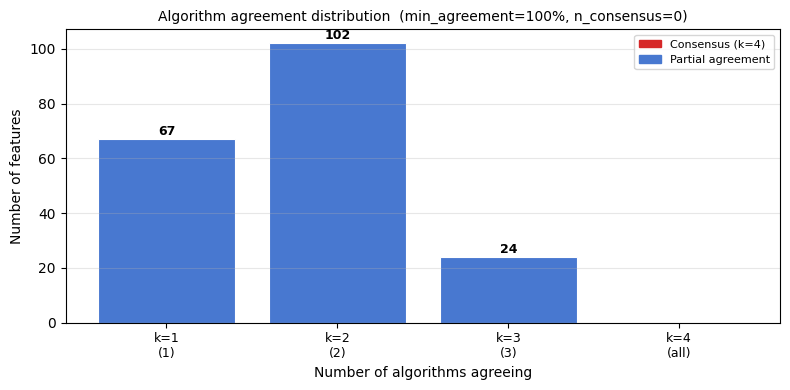

Agreement counts:
  Selected by 1/4 algorithms:   67 features  (20.1%)
  Selected by 2/4 algorithms:  102 features  (30.5%)
  Selected by 3/4 algorithms:   24 features  (7.2%)
  Selected by 4/4 algorithms:    0 features  (0.0%)  ← consensus


In [13]:
if result is not None:
    fig = result.plot_agreement(figsize=(8, 4))
    if fig is not None:
        plt.show()

    # Also print a quick numeric summary
    print('Agreement counts:')
    for k, cnt in result.agreement_counts.items():
        _pct = cnt / result.total_features * 100
        _tag = '  ← consensus' if k == result.n_algorithms else ''
        print(f'  Selected by {k}/{result.n_algorithms} algorithms: {cnt:>4} features  ({_pct:.1f}%){_tag}')

---
## 7 · Heatmap — selection frequency across algorithms

Each row is a feature selected by at least one algorithm.  Each column is one
algorithm.  Colour intensity = bootstrap selection frequency (0 = never selected
in bootstrap resamples, 1 = selected in every resample).  Cells for features not
selected by a given algorithm are shown in grey.

Red outlines mark features in the **consensus set**.  Features at the top of the
heatmap have the highest coverage (selected by all or most algorithms); features
lower down are algorithm-specific.

**Reading the heatmap for Graphene:**
- Top rows (dark blue across all columns) = universally important structural
  descriptors — candidates for physical interpretation.
- Rows where only the RF column is dark = descriptors important through non-linear
  interactions that the linear models cannot capture.
- Rows where only linear columns are dark = descriptors with a clean additive
  relationship to formation energy that the forest misses in the noise of
  higher-order interactions.

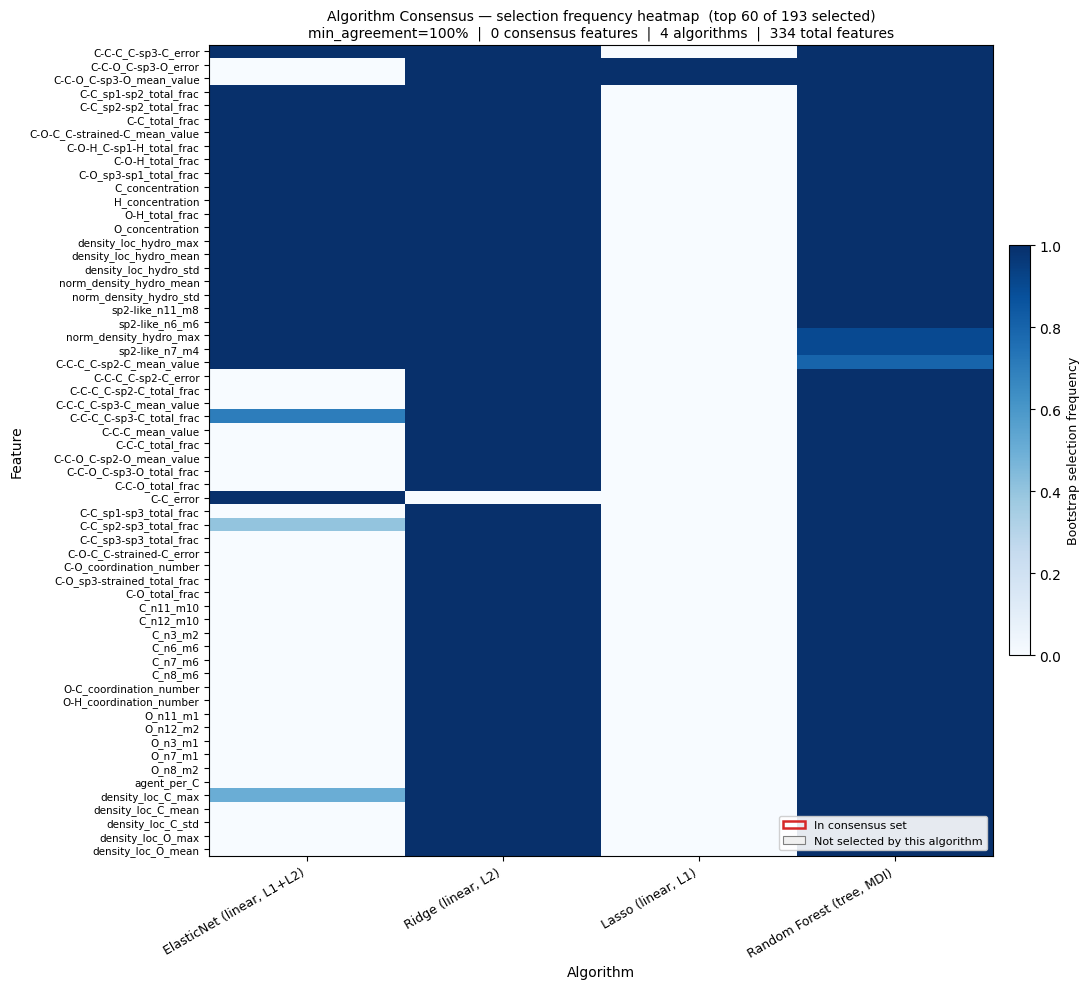

In [15]:
if result is not None:
    # Show up to 60 features — increase max_features to show the full tail
    fig = result.plot_heatmap(max_features=60, figsize=(11, 10))
    if fig is not None:
        plt.show()

---
## 8 · Detailed consensus feature table

The `feature_table` DataFrame holds every feature selected by at least one algorithm,
with columns for coverage, mean selection frequency, and per-algorithm frequencies.
The cells below provide two views:

1. **Consensus subset** — features meeting `min_agreement`, sorted by `mean_freq`.
2. **Partial agreement** — features just below the threshold (useful when `min_agreement=1.0`
   returns too few features for downstream use).

In [17]:
import pandas as pd
import numpy as np

if result is None:
    print('No result — run the cells above first.')
else:
    ft = result.to_dataframe()
    freq_cols = [c for c in ft.columns if c.startswith('freq_')]

    # ── Consensus subset ──────────────────────────────────────────────────────
    consensus_df = ft[ft['in_consensus']].copy()
    _nc = len(consensus_df)
    print(f'Consensus features  (min_agreement={MIN_AGREEMENT:.0%}, n={_nc})')
    print('=' * 70)
    if _nc == 0:
        print('  No features met the agreement threshold.')
        print('  Try lowering MIN_AGREEMENT in the Configuration cell.')
    else:
        _display_cols = ['feature', 'coverage', 'mean_freq', 'n_selected_by'] + freq_cols
        print(consensus_df[_display_cols].to_string(index=False, float_format='{:.3f}'.format))

    print()

    # ── Partial agreement (one algorithm short of consensus) ──────────────────
    _min_k = max(1, result.n_algorithms - 1)
    partial_df = ft[
        (ft['n_selected_by'] == _min_k) & (~ft['in_consensus'])
    ].head(20)
    _np = len(partial_df)
    print(f'Partial agreement features  (selected by {_min_k}/{result.n_algorithms} algorithms, n={_np})')
    print('=' * 70)
    if _np == 0:
        print('  None.')
    else:
        _display_cols = ['feature', 'coverage', 'mean_freq'] + freq_cols
        print(partial_df[_display_cols].head(15).to_string(index=False, float_format='{:.3f}'.format))
        if _np > 15:
            print(f'  ... ({_np - 15} more rows)')

Consensus features  (min_agreement=100%, n=0)
  No features met the agreement threshold.
  Try lowering MIN_AGREEMENT in the Configuration cell.

Partial agreement features  (selected by 3/4 algorithms, n=20)
                      feature  coverage  mean_freq  freq_eln  freq_rdg  freq_las  freq_rf
          C-C-C_C-sp3-C_error     0.750      1.000     1.000     1.000     0.000    1.000
          C-C-O_C-sp3-O_error     0.750      1.000     0.000     1.000     1.000    1.000
     C-C-O_C-sp3-O_mean_value     0.750      1.000     0.000     1.000     1.000    1.000
       C-C_sp1-sp2_total_frac     0.750      1.000     1.000     1.000     0.000    1.000
       C-C_sp2-sp2_total_frac     0.750      1.000     1.000     1.000     0.000    1.000
               C-C_total_frac     0.750      1.000     1.000     1.000     0.000    1.000
C-O-C_C-strained-C_mean_value     0.750      1.000     1.000     1.000     0.000    1.000
     C-O-H_C-sp1-H_total_frac     0.750      1.000     1.000     1.000 

---
## 9 · Sensitivity: what changes with min_agreement?

The cell below sweeps `min_agreement` from strict (1.0) to majority vote (0.5) and
shows how many features are included at each level.  This gives you a feel for how
many additional features you gain by relaxing the threshold — useful for deciding
whether to stick with the strict consensus or accept partial agreement.

Feature count vs min_agreement  (total features: 334)
   min_agree  n_features  % of total  example threshold
  --------------------------------------------------------
        1.00           0        0.0%  4/4 must agree  <- current
        0.75          24        7.2%  3/4 must agree
        0.50         126       37.7%  2/4 must agree
        0.25         193       57.8%  1/4 must agree



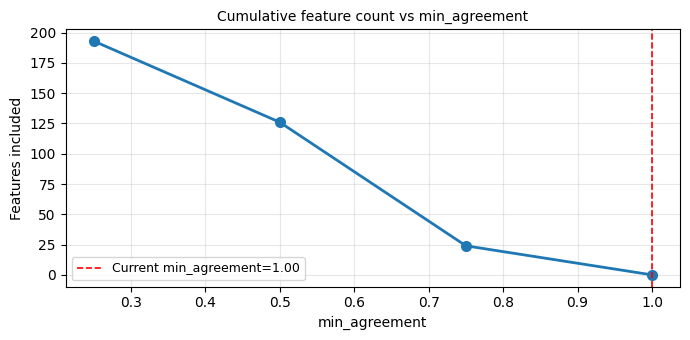

In [21]:
if result is None:
    print('No result — run the cells above first.')
else:
    ft = result.to_dataframe()
    n_total = result.total_features

    print(f'Feature count vs min_agreement  (total features: {n_total})')
    print('=' * 60)
    print(f"  {'min_agree':>10}  {'n_features':>10}  {'% of total':>10}  {'example threshold'}")
    print('  ' + '-' * 56)

    n_algs = result.n_algorithms
    for k in range(n_algs, 0, -1):
        _ma  = k / n_algs
        _cnt = int((ft['n_selected_by'] >= k).sum())
        _pct = _cnt / n_total * 100
        _tag = '  <- current' if abs(_ma - MIN_AGREEMENT) < 1e-6 else ''
        _kof = f'{k}/{n_algs} must agree'
        print(f'  {_ma:>10.2f}  {_cnt:>10}  {_pct:>9.1f}%  {_kof}{_tag}')

    print()

    # Simple bar chart of cumulative coverage
    import matplotlib.pyplot as plt
    _ks   = list(range(n_algs, 0, -1))
    _cnts = [(ft['n_selected_by'] >= k).sum() for k in _ks]
    _mas  = [k / n_algs for k in _ks]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(_mas, _cnts, 'o-', linewidth=2, markersize=7, color='tab:blue')
    ax.axvline(MIN_AGREEMENT, color='red', linestyle='--', linewidth=1.2,
               label=f'Current min_agreement={MIN_AGREEMENT:.2f}')
    ax.set_xlabel('min_agreement', fontsize=10)
    ax.set_ylabel('Features included', fontsize=10)
    ax.set_title('Cumulative feature count vs min_agreement', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 10 · Applying the consensus features

### Use the consensus features for downstream modelling

```python
consensus_feats = result.consensus_features          # list of feature names
X_train_con     = X_train[consensus_feats]           # slice training data
X_test_con      = X_test[consensus_feats]            # slice test data (held-out)
```

### Inspect per-algorithm details

```python
# Full PipelineResult for any algorithm
rf_pipeline = result.algorithm_results['rf'].pipeline
print(rf_pipeline.nested_cv_result.mean_score)

# Bootstrap selection frequencies for RF
rf_freqs = result.algorithm_results['rf'].freq_map   # dict: feature -> frequency
```

### Combine with threshold optimisation

For maximum rigour, combine both tools:

1. Run `ThresholdOptimizer` (per algorithm, or just for `rf`) to find the optimal
   `stability_threshold` for your dataset.
2. Run `AlgorithmConsensus` with that threshold across all algorithms.
3. The consensus features selected at the optimised threshold are the tightest
   possible signal set.

```python
from threshold_optimizer import ThresholdOptimizer
from algorithm_consensus import AlgorithmConsensus
from sklearn.model_selection import train_test_split

# Step 0: random split (use stratify=y for classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

# Step 1: find optimal threshold for RF on this dataset
opt = ThresholdOptimizer(X_train, y_train, task_type='regression').run()
best_thr = opt.best.threshold

# Step 2: run consensus with that threshold
consensus = AlgorithmConsensus(
    algorithms   = ['eln', 'rdg', 'las', 'rf'],
    base_params  = dict(stability_threshold=best_thr, ...),
).fit(X_train, y_train, task_type='regression')

print('Final consensus features:', consensus.consensus_features)
```

### Interpreting the Graphene results

In the MD descriptor space for Graphene Oxide Bulk, consensus features typically
correspond to fundamental geometric quantities that govern formation energy:

* **Coordination-related descriptors** — local bonding environment around C and O atoms
* **Short-range pair correlations** — dominant peaks in the pair distribution function
* **Bond angle distributions** — C–O–C, O–C–O angular geometry

Algorithm-specific (non-consensus) features often correspond to higher-order
correlations captured by the RF but invisible to linear models, or to weakly-linear
secondary correlates that survive only under the softer L2 ridge penalty.